# Matrix Spike (MS) Drift Detection

This notebook continues the Matrix Spike historical time-series analysis by testing whether target-relative deviations become sustained over time.

The workflow is:

1. load and validate Matrix Spike records;
2. recreate the same **Scheme–Analyte–Unit** historical series used in the time-series notebook;
3. calculate deviation from the internal target;
4. normalise each deviation to its corresponding Warning and Failure limits;
5. calculate rolling historical behaviour;
6. identify sustained same-direction movement at the Warning and Failure boundaries;
7. retain the existing `STANDARD_STATUS` alongside the drift result for comparison.

### What the drift result means

A single unusual result is not automatically treated as drift. Drift is identified only when the rolling historical signal remains beyond the relevant normalised boundary for consecutive observations in the same direction.

The analysis uses:

- a rolling window of **10 observations**;
- **3 consecutive rolling boundary breaches** in the same direction;
- the Warning and Failure limits already present in the Matrix Spike data;
- `STANDARD_STATUS` as the existing row-level QC classification.


## 1. Imports


In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the supplied Matrix Spike data


In [2]:
# Search the working repository for the supplied QC workbook.
search_locations = [Path("."), Path("..")]
workbook_matches = []

for location in search_locations:
    workbook_matches.extend(location.rglob("QC Anomaly Training Data*.xlsx"))

workbook_matches = sorted({p.resolve() for p in workbook_matches}, key=lambda p: str(p))

if not workbook_matches:
    raise FileNotFoundError(
        "Could not find a QC Anomaly Training Data workbook. "
        "Place the supplied workbook in the project/repository."
    )

# If duplicate copies exist, only proceed automatically when they are byte-identical.
if len(workbook_matches) > 1:
    def sha256(path):
        h = hashlib.sha256()
        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b""):
                h.update(chunk)
        return h.hexdigest()

    digests = {p: sha256(p) for p in workbook_matches}
    unique_digests = set(digests.values())

    print("Matching workbooks found:")
    for p in workbook_matches:
        print("-", p)

    if len(unique_digests) != 1:
        raise RuntimeError(
            "Multiple different QC Anomaly Training Data workbooks were found. "
            "Keep only the intended submission workbook in the repository before running."
        )

    print("\nAll matching workbook copies are identical; using the first deterministic path.")

data_file = workbook_matches[0]
print("Using workbook:", data_file)

# keep_default_na=False is required because ANALYTE_CODE contains the legitimate
# analyte code 'NA' (sodium). The default pandas parser would interpret it as missing.
raw = pd.read_excel(
    data_file,
    sheet_name="SPK(MS) Assessment",
    keep_default_na=False
)

raw = raw.dropna(axis=1, how="all")
raw.columns = [str(c).strip().upper() for c in raw.columns]

print(f"Rows loaded from SPK(MS) Assessment: {len(raw):,}")
print(f"Columns loaded: {len(raw.columns):,}")

Using workbook: /mnt/data/QC Anomaly Training Data v2(5).xlsx


Rows loaded from SPK(MS) Assessment: 6,958
Columns loaded: 28


## 3. Validate Matrix Spike scope and available recovery information

This section checks that the worksheet contains the expected Matrix Spike records and the fields required for the analysis.

It also checks whether the information needed to reconstruct recovery percentage is present. If the parent/unspiked result is unavailable, the notebook does not create an estimated recovery value. The drift analysis instead uses the measured result, target, Warning limits and Failure limits that are available in the data.


In [3]:
required_columns = [
    "ANALYTICAL_TYPE", "QC_TYPE", "STD_LOT_CODE", "STD_CODE", "JOB_CODE",
    "NUMERIC_FINAL_VALUE", "ANALYSED_DATE", "SCHEME_CODE", "ANALYTE_CODE",
    "STANDARD_STATUS", "INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE",
    "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_TARGET_VALUE", "UNIT_CODE"
]

missing_columns = [c for c in required_columns if c not in raw.columns]
if missing_columns:
    raise ValueError(f"Required Matrix Spike columns are missing: {missing_columns}")

text_columns = [
    "ANALYTICAL_TYPE", "QC_TYPE", "STD_LOT_CODE", "STD_CODE", "JOB_CODE",
    "SCHEME_CODE", "ANALYTE_CODE", "STANDARD_STATUS", "UNIT_CODE"
]
for col in text_columns:
    raw[col] = raw[col].astype(str).str.strip()

numeric_columns = [
    "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
    "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE"
]
for col in numeric_columns:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw["ANALYSED_DATE"] = pd.to_datetime(raw["ANALYSED_DATE"], errors="coerce")

# Keep only Matrix Spike rows, even though the supplied sheet is already MS-specific.
ms = raw[
    raw["ANALYTICAL_TYPE"].str.casefold().eq("spike") &
    raw["QC_TYPE"].str.casefold().eq("ms")
].copy()

parent_numeric_count = 0
if "PARENT_NUMERIC_FINAL_VALUE" in ms.columns:
    parent_numeric_count = pd.to_numeric(
        ms["PARENT_NUMERIC_FINAL_VALUE"], errors="coerce"
    ).notna().sum()

print(f"Matrix Spike rows retained: {len(ms):,}")
print("ANALYTICAL_TYPE values:", ms["ANALYTICAL_TYPE"].value_counts(dropna=False).to_dict())
print("QC_TYPE values:", ms["QC_TYPE"].value_counts(dropna=False).to_dict())
print("STD_LOT_CODE values:", ms["STD_LOT_CODE"].value_counts(dropna=False).to_dict())
print("Rows with numeric PARENT_NUMERIC_FINAL_VALUE:", int(parent_numeric_count))
print("Rows with ANALYTE_CODE == 'NA':", int((ms["ANALYTE_CODE"] == "NA").sum()))
print("Unique analytes (including 'NA'):", ms["ANALYTE_CODE"].replace("", np.nan).nunique())

if parent_numeric_count == 0:
    print(
        "\nRecovery percentage is not reconstructed: the supplied parent/unspiked value "
        "is not populated and no spike-added concentration field is available."
    )

Matrix Spike rows retained: 6,958
ANALYTICAL_TYPE values: {'Spike': 6958}
QC_TYPE values: {'MS': 6958}
STD_LOT_CODE values: {'OREAS_502C': 6958}
Rows with numeric PARENT_NUMERIC_FINAL_VALUE: 0
Rows with ANALYTE_CODE == 'NA': 86
Unique analytes (including 'NA'): 58

Recovery percentage is not reconstructed: the supplied parent/unspiked value is not populated and no spike-added concentration field is available.


## 4. Recreate the historical series from the time-series notebook

This section keeps the same unit of historical comparison as `MS_time_series_analysis.ipynb`:

**`SCHEME_CODE + ANALYTE_CODE + UNIT_CODE`**

Each combination forms one chronological Matrix Spike series.

`JOB_CODE`, `STD_LOT_CODE`, `STD_CODE`, and `INSTRUMENT_ID` are retained as context fields so flagged behaviour can be traced back to the original records, but they do not split the historical series.

For every row:

`DEVIATION = NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE`

A deviation of `0` means the measured result is exactly on its internal target. Positive values are above target and negative values are below target.


In [4]:
history_required = [
    "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE", "ANALYSED_DATE",
    "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
    "INTERNAL_MIN_WARNING_VALUE", "INTERNAL_MAX_WARNING_VALUE",
    "INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE"
]

valid_history_mask = (
    ms["SCHEME_CODE"].ne("") &
    ms["ANALYTE_CODE"].ne("") &
    ms["UNIT_CODE"].ne("") &
    ms[history_required[3:]].notna().all(axis=1)
)

ms_drift = (
    ms.loc[valid_history_mask]
    .copy()
    .sort_values(["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE", "ANALYSED_DATE"])
    .reset_index(drop=True)
)

# Same target-relative deviation used in the preceding time-series notebook.
ms_drift["DEVIATION"] = (
    ms_drift["NUMERIC_FINAL_VALUE"] - ms_drift["INTERNAL_TARGET_VALUE"]
)

# Supplied QC limits on the same deviation-from-target scale.
ms_drift["LOWER_WARNING_DEVIATION"] = (
    ms_drift["INTERNAL_MIN_WARNING_VALUE"] - ms_drift["INTERNAL_TARGET_VALUE"]
)
ms_drift["UPPER_WARNING_DEVIATION"] = (
    ms_drift["INTERNAL_MAX_WARNING_VALUE"] - ms_drift["INTERNAL_TARGET_VALUE"]
)
ms_drift["LOWER_FAILURE_DEVIATION"] = (
    ms_drift["INTERNAL_MIN_VALUE"] - ms_drift["INTERNAL_TARGET_VALUE"]
)
ms_drift["UPPER_FAILURE_DEVIATION"] = (
    ms_drift["INTERNAL_MAX_VALUE"] - ms_drift["INTERNAL_TARGET_VALUE"]
)

group_sizes = (
    ms_drift
    .groupby(["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"])
    .size()
    .rename("N_OBSERVATIONS")
    .sort_values(ascending=False)
)

print(f"Original Matrix Spike rows: {len(ms):,}")
print(f"Rows usable for historical drift analysis: {len(ms_drift):,}")
print(f"Rows excluded for missing required historical fields: {len(ms) - len(ms_drift):,}")
print(f"Historical Scheme–Analyte–Unit series: {len(group_sizes):,}")
print(f"Minimum observations in a series: {int(group_sizes.min()):,}")
print(f"Median observations in a series: {group_sizes.median():.0f}")
print(f"Maximum observations in a series: {int(group_sizes.max()):,}")
print(
    "Date range:",
    ms_drift["ANALYSED_DATE"].min(),
    "to",
    ms_drift["ANALYSED_DATE"].max()
)

display(
    ms_drift[
        [
            "JOB_CODE", "STD_LOT_CODE", "SCHEME_CODE", "ANALYTE_CODE",
            "UNIT_CODE", "ANALYSED_DATE", "NUMERIC_FINAL_VALUE",
            "INTERNAL_TARGET_VALUE", "DEVIATION", "STANDARD_STATUS"
        ]
    ].head()
)

Original Matrix Spike rows: 6,958
Rows usable for historical drift analysis: 6,958
Rows excluded for missing required historical fields: 0
Historical Scheme–Analyte–Unit series: 87
Minimum observations in a series: 22
Median observations in a series: 51
Maximum observations in a series: 238
Date range: 2020-06-26 04:23:55 to 2021-11-10 07:12:48


,JOB_CODE,STD_LOT_CODE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,DEVIATION,STANDARD_STATUS
0,TSV_LB0002670477,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-06-29 11:14:08,1.234450,0.779,0.455450,Pass
1,TSV_LB0002766490,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-08 05:53:05,1.543689,0.779,0.764689,Pass
2,TSV_LB0002766490,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-08 06:49:31,1.650000,0.779,0.871000,UpperWarning
3,TSV_LB0002766700,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-09 12:36:17,1.275510,0.779,0.496510,Pass
4,TSV_LB0002766700,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-10 03:22:44,1.661376,0.779,0.882376,UpperWarning


## 5. Normalise target-relative deviation to the QC boundaries

Warning and Failure ranges can have different distances above and below the target, so positive and negative deviations are scaled using the relevant directional limit.

After normalisation:

- `0` = the internal target;
- `+1` = the upper Warning or Failure boundary;
- `-1` = the lower Warning or Failure boundary;
- values between `-1` and `+1` remain inside that boundary;
- values beyond `±1` are outside that boundary.

Two normalised measures are created:

- `Normalized_Warning` compares the result with the Warning limits;
- `Normalized_Failure` compares the result with the Failure limits.

This places analytes with different numerical scales onto a common target-relative scale without changing the original measured values.


In [5]:
def directional_normalise(frame, lower_col, upper_col):
    """Normalise target-relative deviation using the corresponding supplied bound."""
    deviation = frame["DEVIATION"]
    target = frame["INTERNAL_TARGET_VALUE"]

    upper_distance = frame[upper_col] - target
    lower_distance = target - frame[lower_col]

    normalised = pd.Series(np.nan, index=frame.index, dtype=float)

    upper_mask = (deviation >= 0) & (upper_distance > 0)
    lower_mask = (deviation < 0) & (lower_distance > 0)

    normalised.loc[upper_mask] = (
        deviation.loc[upper_mask] / upper_distance.loc[upper_mask]
    )
    normalised.loc[lower_mask] = (
        deviation.loc[lower_mask] / lower_distance.loc[lower_mask]
    )

    return normalised.replace([np.inf, -np.inf], np.nan)


ms_drift["Normalized_Warning"] = directional_normalise(
    ms_drift,
    "INTERNAL_MIN_WARNING_VALUE",
    "INTERNAL_MAX_WARNING_VALUE"
)

ms_drift["Normalized_Failure"] = directional_normalise(
    ms_drift,
    "INTERNAL_MIN_VALUE",
    "INTERNAL_MAX_VALUE"
)

print("Normalisation complete.")
print(
    "Maximum absolute warning-normalised value:",
    round(ms_drift["Normalized_Warning"].abs().max(), 4)
)
print(
    "Maximum absolute failure-normalised value:",
    round(ms_drift["Normalized_Failure"].abs().max(), 4)
)

# Keep the most extreme row visible rather than modifying it.
extreme_idx = ms_drift["Normalized_Warning"].abs().idxmax()
print("\nMost extreme supplied MS observation on the warning-normalised scale:")
display(
    ms_drift.loc[
        [extreme_idx],
        [
            "JOB_CODE", "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE",
            "ANALYSED_DATE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
            "Normalized_Warning", "Normalized_Failure", "STANDARD_STATUS"
        ]
    ]
)

Normalisation complete.
Maximum absolute warning-normalised value: 3256.7314
Maximum absolute failure-normalised value: 2065.6916

Most extreme supplied MS observation on the warning-normalised scale:


,JOB_CODE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,Normalized_Warning,Normalized_Failure,STANDARD_STATUS
62,TSV_LB0004352597,GE_ICP40Q12,AG,MG_KG,2020-11-04 07:56:06,2743.77665,0.779,3256.731395,2065.691649,UpperFailure


The supplied Matrix Spike dataset contains an extremely large AG observation. The largest Warning-normalised value was approximately 3256.7, meaning that this result was far beyond the target-to-Warning-limit distance for that analyte. The calculation is correct for the supplied data, but because this observation is extremely different from the surrounding AG results, it should be treated as an extreme source-data observation and considered carefully when interpreting rolling historical averages.


## 6. Detect sustained drift

For each **Scheme–Analyte–Unit** historical series:

1. observations are sorted by `ANALYSED_DATE`;
2. a rolling mean is calculated over up to 10 observations;
3. **warning drift** is detected when the rolling Warning-normalised value reaches or exceeds `+1` or `-1` for 3 consecutive rolling observations in the same direction;
4. the Failure-normalised rolling signal is then assessed for the same sustained pattern;
5. the first existing non-ignored Warning and Failure dates in `STANDARD_STATUS` are retained for comparison.

### Why consecutive direction matters

Three upper breaches represent sustained upward movement and three lower breaches represent sustained downward movement. Alternating upper and lower breaches are not treated as one drift sequence.

The rolling mean summarises recent historical behaviour and reduces sensitivity to ordinary short-term variation; however, extremely large observations can still influence several consecutive rolling values and therefore require analyst review.


In [6]:
# Drift-detection settings
ROLLING_WINDOW = 10
CONSECUTIVE_REQUIRED = 3
BOUNDARY_LEVEL = 1.0

print("Drift detection settings")
print("------------------------")
print("Rolling window:", ROLLING_WINDOW)
print("Consecutive same-direction rolling breaches required:", CONSECUTIVE_REQUIRED)
print("Normalised Warning/Failure boundary: ±1")

Drift detection settings
------------------------
Rolling window: 10
Consecutive same-direction rolling breaches required: 3
Normalised Warning/Failure boundary: ±1


In [7]:
def first_consecutive_directional_breach(values, dates, threshold=BOUNDARY_LEVEL,
                                         consecutive_required=CONSECUTIVE_REQUIRED):
    """Find the first same-direction run of consecutive threshold breaches."""
    run_direction = None
    run_start = pd.NaT
    run_len = 0

    for value, date in zip(values, dates):
        if pd.isna(value) or abs(value) < threshold:
            run_direction = None
            run_start = pd.NaT
            run_len = 0
            continue

        direction = "Upper" if value > 0 else "Lower"

        if direction == run_direction:
            run_len += 1
        else:
            run_direction = direction
            run_start = date
            run_len = 1

        if run_len >= consecutive_required:
            return True, run_direction, run_start

    return False, None, pd.NaT


def evaluate_ms_series(group):
    """Evaluate one Scheme–Analyte–Unit history for sustained directional drift."""
    g = group.sort_values("ANALYSED_DATE").reset_index(drop=True).copy()

    win = min(ROLLING_WINDOW, len(g))
    min_periods = max(1, win // 2)  # start the rolling signal once half the window is available

    g["ROLLING_WARNING"] = (
        g["Normalized_Warning"]
        .rolling(window=win, min_periods=min_periods)
        .mean()
    )

    warning_detected, warning_direction, warning_start = (
        first_consecutive_directional_breach(
            g["ROLLING_WARNING"],
            g["ANALYSED_DATE"]
        )
    )

    # Evaluate the Failure stage only after sustained Warning drift is detected.
    g["ROLLING_FAILURE"] = (
        g["Normalized_Failure"]
        .rolling(window=win, min_periods=min_periods)
        .mean()
    )

    if warning_detected:
        failure_detected, failure_direction, failure_start = (
            first_consecutive_directional_breach(
                g["ROLLING_FAILURE"],
                g["ANALYSED_DATE"]
            )
        )
    else:
        failure_detected, failure_direction, failure_start = False, None, pd.NaT

    status = g["STANDARD_STATUS"].astype(str)

    warning_mask = (
        status.str.contains("Warning", case=False, na=False) &
        ~status.str.contains("Ignored", case=False, na=False)
    )
    failure_mask = (
        status.str.contains("Failure", case=False, na=False) &
        ~status.str.contains("Ignored", case=False, na=False)
    )

    first_status_warning = (
        g.loc[warning_mask, "ANALYSED_DATE"].min()
        if warning_mask.any() else pd.NaT
    )
    first_status_failure = (
        g.loc[failure_mask, "ANALYSED_DATE"].min()
        if failure_mask.any() else pd.NaT
    )

    valid_warning_roll = g["ROLLING_WARNING"].dropna()
    valid_failure_roll = g["ROLLING_FAILURE"].dropna()

    return {
        "warning_drift_detected": bool(warning_detected),
        "warning_direction": warning_direction,
        "warning_drift_start": warning_start,
        "failure_drift_detected": bool(failure_detected),
        "failure_direction": failure_direction,
        "failure_drift_start": failure_start,
        "current_warning_score": (
            float(valid_warning_roll.iloc[-1]) if not valid_warning_roll.empty else np.nan
        ),
        "peak_abs_warning_score": (
            float(valid_warning_roll.abs().max()) if not valid_warning_roll.empty else np.nan
        ),
        "peak_abs_failure_score": (
            float(valid_failure_roll.abs().max()) if not valid_failure_roll.empty else np.nan
        ),
        "first_status_warning_date": first_status_warning,
        "first_status_failure_date": first_status_failure,
        "n_observations": len(g),
        "n_jobs": g["JOB_CODE"].nunique(),
        "n_instruments": (
            g["INSTRUMENT_ID"].replace("", np.nan).nunique()
            if "INSTRUMENT_ID" in g.columns else np.nan
        )
    }


def detect_ms_drift(frame):
    """Run drift evaluation independently for every Scheme–Analyte–Unit series."""
    rows = []
    group_keys = ["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]

    for keys, group in frame.groupby(group_keys, sort=True):
        result = evaluate_ms_series(group)
        row = dict(zip(group_keys, keys))
        row.update(result)
        rows.append(row)

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["drift_level"] = np.select(
        [out["failure_drift_detected"], out["warning_drift_detected"]],
        ["Failure", "Warning"],
        default="None"
    )

    return (
        out.sort_values(
            ["failure_drift_detected", "warning_drift_detected", "peak_abs_warning_score"],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

## 7. Run the Matrix Spike drift detector


In [8]:
drift_summary = detect_ms_drift(ms_drift)

warning_drift_summary = (
    drift_summary[drift_summary["warning_drift_detected"]]
    .copy()
    .reset_index(drop=True)
)

failure_drift_summary = (
    drift_summary[drift_summary["failure_drift_detected"]]
    .copy()
    .reset_index(drop=True)
)

print(f"Historical Scheme–Analyte–Unit series analysed : {len(drift_summary):,}")
print(f"Warning-drift review series                     : {len(warning_drift_summary):,}")
print(f"Failure-drift review series                     : {len(failure_drift_summary):,}")
print(f"Series for ANALYTE_CODE == 'NA'                 : {(drift_summary['ANALYTE_CODE'] == 'NA').sum():,}")

print("\nDrift level counts:")
print(drift_summary["drift_level"].value_counts(dropna=False).to_string())

Historical Scheme–Analyte–Unit series analysed : 87
Warning-drift review series                     : 42
Failure-drift review series                     : 27
Series for ANALYTE_CODE == 'NA'                 : 1

Drift level counts:
drift_level
None       45
Failure    27
Warning    15


In [9]:
print("Top warning-drift review series:")
display(
    warning_drift_summary[
        [
            "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE",
            "warning_direction", "warning_drift_start",
            "peak_abs_warning_score", "current_warning_score",
            "first_status_warning_date", "first_status_failure_date",
            "n_observations", "n_jobs", "n_instruments", "drift_level"
        ]
    ].head(15)
)

print("\nTop failure-drift review series:")
display(
    failure_drift_summary[
        [
            "SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE",
            "failure_direction", "failure_drift_start",
            "peak_abs_failure_score",
            "first_status_warning_date", "first_status_failure_date",
            "n_observations", "n_jobs", "n_instruments", "drift_level"
        ]
    ].head(15)
)

Top warning-drift review series:


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,warning_direction,warning_drift_start,peak_abs_warning_score,current_warning_score,first_status_warning_date,first_status_failure_date,n_observations,n_jobs,n_instruments,drift_level
0,GE_ICP40Q12,AG,MG_KG,Upper,2020-11-04 07:56:06,326.140814,0.664226,2020-07-08 06:49:31,2020-11-04 07:56:06,157,128,0,Failure
1,GE_ICP40Q12,SE,MG_KG,Upper,2020-07-10 03:22:44,111.570107,2.391001,2020-07-21 01:12:52,2020-07-08 05:53:05,119,97,0,Failure
2,GE_IMS40Q12,TL,MG_KG,Upper,2020-07-28 11:23:33,38.663029,0.131002,2020-07-09 13:10:26,NaT,51,42,0,Failure
3,GE_ICP40Q12,PB,MG_KG,Upper,2020-07-23 15:28:18,6.599683,6.599683,2020-07-08 06:49:31,2020-07-28 01:02:28,164,131,0,Failure
4,GE_ICP40Q12,P,PERC,Upper,2020-11-04 07:56:06,5.967882,0.056513,2020-07-27 01:32:30,2020-11-04 07:56:06,77,57,0,Failure
5,GE_IMS40Q12,CD,MG_KG,Upper,2020-11-05 20:15:06,5.390887,3.946771,2020-11-09 11:51:40,2020-11-05 17:11:34,23,17,0,Failure
6,GE_ICP40Q12,U,MG_KG,Lower,2020-11-17 04:51:51,4.777107,-3.765018,2020-07-15 13:14:22,2020-11-04 07:56:06,47,37,0,Failure
7,GE_IMS40Q12,CO,MG_KG,Upper,2020-09-04 17:36:02,4.628892,1.397340,2020-10-03 05:00:48,2020-11-05 17:11:34,30,22,0,Failure
8,GE_ICP40Q12,MO,MG_KG,Upper,2020-07-20 05:29:35,4.266409,-0.576559,2020-07-08 05:53:05,2020-06-29 11:14:08,136,111,0,Failure
9,GE_ICP40Q12,CA,PERC,Upper,2020-08-25 03:34:49,3.660928,-0.114913,2020-07-15 09:40:47,2020-11-04 07:56:06,76,58,0,Failure



Top failure-drift review series:


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,failure_direction,failure_drift_start,peak_abs_failure_score,first_status_warning_date,first_status_failure_date,n_observations,n_jobs,n_instruments,drift_level
0,GE_ICP40Q12,AG,MG_KG,Upper,2020-11-04 07:56:06,206.865803,2020-07-08 06:49:31,2020-11-04 07:56:06,157,128,0,Failure
1,GE_ICP40Q12,SE,MG_KG,Upper,2020-07-10 03:22:44,70.764806,2020-07-21 01:12:52,2020-07-08 05:53:05,119,97,0,Failure
2,GE_IMS40Q12,TL,MG_KG,Upper,2021-03-30 09:56:12,24.524685,2020-07-09 13:10:26,NaT,51,42,0,Failure
3,GE_ICP40Q12,PB,MG_KG,Upper,2020-09-25 01:56:18,4.185988,2020-07-08 06:49:31,2020-07-28 01:02:28,164,131,0,Failure
4,GE_ICP40Q12,P,PERC,Upper,2020-11-04 07:56:06,3.785584,2020-07-27 01:32:30,2020-11-04 07:56:06,77,57,0,Failure
5,GE_IMS40Q12,CD,MG_KG,Upper,2020-11-05 20:15:06,3.420073,2020-11-09 11:51:40,2020-11-05 17:11:34,23,17,0,Failure
6,GE_ICP40Q12,U,MG_KG,Lower,2020-11-17 04:51:51,3.029799,2020-07-15 13:14:22,2020-11-04 07:56:06,47,37,0,Failure
7,GE_IMS40Q12,CO,MG_KG,Upper,2020-09-04 17:36:02,2.937415,2020-10-03 05:00:48,2020-11-05 17:11:34,30,22,0,Failure
8,GE_ICP40Q12,MO,MG_KG,Upper,2020-09-25 03:26:01,2.707307,2020-07-08 05:53:05,2020-06-29 11:14:08,136,111,0,Failure
9,GE_ICP40Q12,CA,PERC,Upper,2020-08-25 03:34:49,2.321483,2020-07-15 09:40:47,2020-11-04 07:56:06,76,58,0,Failure


### 7.1 Compare historical drift with existing CCLAS classifications

`STANDARD_STATUS` is retained as the existing row-level CCLAS classification. The historical drift result is calculated across a complete **Scheme–Analyte–Unit** series.

This comparison does **not** redefine the existing CCLAS result. It shows which row-level classifications occur inside series that have been identified for sustained historical drift, so the additional historical context can be reviewed alongside the existing QC outcome.


In [10]:
# Summarise existing CCLAS row-level classifications within each historical series.
group_keys = ["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]

status_summary = (
    ms_drift
    .groupby(group_keys + ["STANDARD_STATUS"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

expected_statuses = [
    "Pass",
    "UpperWarning",
    "LowerWarning",
    "UpperFailure",
    "LowerFailure",
    "IgnoredUpperFailure",
    "IgnoredLowerFailure"
]

for status in expected_statuses:
    if status not in status_summary.columns:
        status_summary[status] = 0

status_summary["CCLAS_Pass_Count"] = status_summary["Pass"]

status_summary["CCLAS_Warning_Count"] = (
    status_summary["UpperWarning"] +
    status_summary["LowerWarning"]
)

status_summary["CCLAS_Active_Failure_Count"] = (
    status_summary["UpperFailure"] +
    status_summary["LowerFailure"]
)

status_summary["CCLAS_Ignored_Failure_Count"] = (
    status_summary["IgnoredUpperFailure"] +
    status_summary["IgnoredLowerFailure"]
)

drift_cclas_comparison = drift_summary.merge(
    status_summary[
        group_keys + [
            "CCLAS_Pass_Count",
            "CCLAS_Warning_Count",
            "CCLAS_Active_Failure_Count",
            "CCLAS_Ignored_Failure_Count"
        ]
    ],
    on=group_keys,
    how="left"
)

print("Historical drift candidates compared with existing CCLAS classifications:")

display(
    drift_cclas_comparison[
        drift_cclas_comparison["drift_level"] != "None"
    ][
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "drift_level",
            "warning_direction",
            "failure_direction",
            "CCLAS_Pass_Count",
            "CCLAS_Warning_Count",
            "CCLAS_Active_Failure_Count",
            "CCLAS_Ignored_Failure_Count",
            "n_observations"
        ]
    ]
    .sort_values(
        ["drift_level", "CCLAS_Active_Failure_Count"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


Historical drift candidates compared with existing CCLAS classifications:


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,drift_level,warning_direction,failure_direction,CCLAS_Pass_Count,CCLAS_Warning_Count,CCLAS_Active_Failure_Count,CCLAS_Ignored_Failure_Count,n_observations
0,GE_ICP40Q12,BI,MG_KG,Failure,Lower,Lower,34,20,85,9,148
1,GE_ICP40Q12,SE,MG_KG,Failure,Upper,Upper,17,16,81,5,119
2,GE_ICP40Q12,MO,MG_KG,Failure,Upper,Upper,58,24,42,12,136
3,GE_ICP40Q12,ZN,MG_KG,Failure,Upper,Upper,86,36,38,16,176
4,GE_ICP40Q12,CU,MG_KG,Failure,Upper,Upper,120,24,27,4,175
5,GE_ICP40Q12,AS,MG_KG,Failure,Upper,Upper,95,41,22,7,165
6,GE_ICP40Q12,PB,MG_KG,Failure,Upper,Upper,94,31,18,21,164
7,GE_ICP40Q12,U,MG_KG,Failure,Lower,Lower,8,7,11,21,47
8,GE_ICP40Q12,NI,MG_KG,Failure,Lower,Lower,28,8,11,4,51
9,GE_ICP40Q12,TA,MG_KG,Failure,Lower,Lower,11,8,10,6,35


### 7.2 Drift direction summary

The detector records whether sustained historical movement is **Upper** or **Lower** relative to target.

This is useful for Matrix Spike review because sustained movement can occur on either side of the target. The direction is reported separately from the existing CCLAS row-level classification.


Warning-stage drift by direction:
warning_direction
Upper    25
Lower    17

Failure-stage drift by direction:
failure_direction
Upper    18
Lower     9


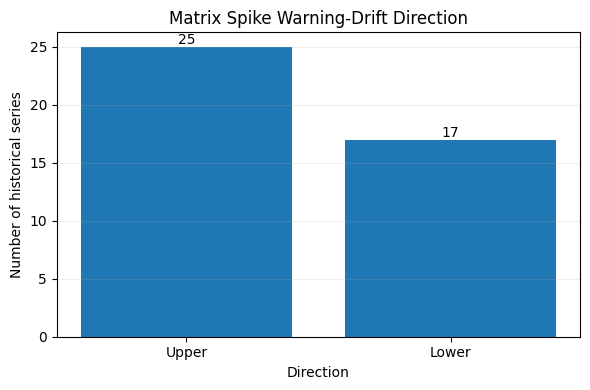

In [11]:
print("Warning-stage drift by direction:")
warning_direction_counts = (
    warning_drift_summary["warning_direction"]
    .value_counts(dropna=False)
    .reindex(["Upper", "Lower"], fill_value=0)
)
print(warning_direction_counts.to_string())

print("\nFailure-stage drift by direction:")
failure_direction_counts = (
    failure_drift_summary["failure_direction"]
    .value_counts(dropna=False)
    .reindex(["Upper", "Lower"], fill_value=0)
)
print(failure_direction_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    warning_direction_counts.index,
    warning_direction_counts.values
)

ax.set_title("Matrix Spike Warning-Drift Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Number of historical series")
ax.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, warning_direction_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(value)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### 7.3 Compare drift onset with existing CCLAS Warning and Failure dates

The historical drift detector and `STANDARD_STATUS` measure different things.

The comparison below therefore does not claim that one replaces the other. It records whether the first sustained historical drift sequence occurred before, at, or after the first existing non-ignored CCLAS Warning or Failure recorded in the same historical series.

A positive day difference means the drift sequence began earlier than the first corresponding CCLAS status. A negative value means the corresponding CCLAS status occurred first. Missing values mean that no corresponding non-ignored CCLAS status was present in that series.


In [12]:
timing_comparison = drift_summary.copy()

timing_comparison["days_warning_drift_vs_cclas_warning"] = (
    timing_comparison["first_status_warning_date"] -
    timing_comparison["warning_drift_start"]
).dt.total_seconds() / 86400

timing_comparison["days_failure_drift_vs_cclas_failure"] = (
    timing_comparison["first_status_failure_date"] -
    timing_comparison["failure_drift_start"]
).dt.total_seconds() / 86400

print("Warning-drift timing comparison:")
display(
    timing_comparison[
        timing_comparison["warning_drift_detected"]
    ][
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "warning_direction",
            "warning_drift_start",
            "first_status_warning_date",
            "days_warning_drift_vs_cclas_warning"
        ]
    ]
    .sort_values("warning_drift_start")
    .reset_index(drop=True)
)

print("\nFailure-drift timing comparison:")
display(
    timing_comparison[
        timing_comparison["failure_drift_detected"]
    ][
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "failure_direction",
            "failure_drift_start",
            "first_status_failure_date",
            "days_failure_drift_vs_cclas_failure"
        ]
    ]
    .sort_values("failure_drift_start")
    .reset_index(drop=True)
)


Warning-drift timing comparison:


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,warning_direction,warning_drift_start,first_status_warning_date,days_warning_drift_vs_cclas_warning
0,GE_ICP40Q12,ZN,MG_KG,Upper,2020-07-09 12:36:17.000,2020-07-08 05:53:05,-1.280000
1,GE_ICP40Q12,SE,MG_KG,Upper,2020-07-10 03:22:44.000,2020-07-21 01:12:52,10.909815
2,GE_ICP40Q12,BI,MG_KG,Lower,2020-07-10 03:22:44.000,2020-07-15 09:43:25,5.264363
3,GE_ICP40Q12,MO,MG_KG,Upper,2020-07-20 05:29:35.000,2020-07-08 05:53:05,-11.983681
4,GE_IMS40Q12,AG,MG_KG,Upper,2020-07-20 12:16:56.000,2020-06-30 13:28:40,-19.950185
5,GE_ICP40Q12,AS,MG_KG,Upper,2020-07-23 14:48:00.000,2020-07-15 09:22:11,-8.226262
6,GE_ICP40Q12,PB,MG_KG,Upper,2020-07-23 15:28:18.000,2020-07-08 06:49:31,-15.360266
7,GE_ICP40Q12,RB,MG_KG,Upper,2020-07-27 11:26:26.000,2020-09-01 12:59:00,36.064282
8,GE_IMS40Q12,NI,MG_KG,Upper,2020-07-27 14:37:38.000,2020-07-20 12:32:42,-7.086759
9,GE_IMS40Q12,TL,MG_KG,Upper,2020-07-28 11:23:33.000,2020-07-09 13:10:26,-18.925775



Failure-drift timing comparison:


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,failure_direction,failure_drift_start,first_status_failure_date,days_failure_drift_vs_cclas_failure
0,GE_ICP40Q12,SE,MG_KG,Upper,2020-07-10 03:22:44.000,2020-07-08 05:53:05.000,-1.895590
1,GE_ICP40Q12,ZN,MG_KG,Upper,2020-07-15 13:18:09.000,2020-06-29 11:14:08.000,-16.086123
2,GE_IMS40Q12,AG,MG_KG,Upper,2020-07-22 01:02:01.000,2020-12-31 13:29:25.000,162.519028
3,GE_ICP40Q12,BI,MG_KG,Lower,2020-07-27 07:42:35.000,2020-06-29 11:14:08.000,-27.853090
4,GE_ICP40Q12,V,MG_KG,Upper,2020-08-25 03:34:49.000,2020-11-04 07:56:06.000,71.181447
5,GE_ICP40Q12,CA,PERC,Upper,2020-08-25 03:34:49.000,2020-11-04 07:56:06.000,71.181447
6,GE_IMS40Q12,NI,MG_KG,Upper,2020-08-28 02:04:14.000,2020-11-13 17:11:38.000,77.630139
7,GE_IMS40Q12,CO,MG_KG,Upper,2020-09-04 17:36:02.000,2020-11-05 17:11:34.000,61.983009
8,GE_ICP40Q12,PB,MG_KG,Upper,2020-09-25 01:56:18.000,2020-07-28 01:02:28.000,-59.037384
9,GE_ICP40Q12,AS,MG_KG,Upper,2020-09-25 03:26:01.000,2020-06-29 11:14:08.000,-87.674919


### 7.4 Diagnostic: ignored Failure rows

Ignored Failure rows remain in the current historical series because the available Matrix Spike information does not establish a confirmed Datamine rule requiring their removal from this historical prototype.

Their presence is therefore reported explicitly for review rather than silently excluded. Treatment of ignored results should be confirmed with Datamine before operational deployment.


In [13]:
ignored_mask = ms_drift["STANDARD_STATUS"].isin(
    [
        "IgnoredUpperFailure",
        "IgnoredLowerFailure"
    ]
)

print(
    "Matrix Spike rows with ignored Failure status:",
    int(ignored_mask.sum())
)

print(
    "Percentage of analysed Matrix Spike rows:",
    round(100 * ignored_mask.mean(), 2),
    "%"
)


Matrix Spike rows with ignored Failure status: 378
Percentage of analysed Matrix Spike rows: 5.43 %


## 8. Trace a flagged series back to the original QC records

A drift flag is a historical review signal. It does not replace `STANDARD_STATUS`.

The helper below returns the original rows for a selected **Scheme–Analyte–Unit** series so the analyst can inspect:

- job and standard context;
- analysis dates;
- measured values;
- target values;
- Warning and Failure limits;
- normalised values;
- existing row-level QC status.

This provides traceability from the summary drift flag back to the underlying measurements.


In [14]:
def get_series_trace(frame, scheme_code, analyte_code, unit_code):
    cols = [
        "JOB_CODE", "STD_LOT_CODE", "STD_CODE", "SCHEME_CODE", "ANALYTE_CODE",
        "UNIT_CODE", "ANALYSED_DATE", "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
        "INTERNAL_MIN_WARNING_VALUE", "INTERNAL_MAX_WARNING_VALUE",
        "INTERNAL_MIN_VALUE", "INTERNAL_MAX_VALUE", "DEVIATION",
        "Normalized_Warning", "Normalized_Failure", "STANDARD_STATUS"
    ]
    if "INSTRUMENT_ID" in frame.columns:
        cols.append("INSTRUMENT_ID")

    return (
        frame[
            (frame["SCHEME_CODE"] == scheme_code) &
            (frame["ANALYTE_CODE"] == analyte_code) &
            (frame["UNIT_CODE"] == unit_code)
        ][cols]
        .sort_values("ANALYSED_DATE")
        .reset_index(drop=True)
    )

if not warning_drift_summary.empty:
    first_flag = warning_drift_summary.iloc[0]
    example_trace = get_series_trace(
        ms_drift,
        first_flag["SCHEME_CODE"],
        first_flag["ANALYTE_CODE"],
        first_flag["UNIT_CODE"]
    )
    print(
        "Trace example:",
        first_flag["SCHEME_CODE"],
        first_flag["ANALYTE_CODE"],
        first_flag["UNIT_CODE"]
    )
    display(example_trace.head(12))

Trace example: GE_ICP40Q12 AG MG_KG


,JOB_CODE,STD_LOT_CODE,STD_CODE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,INTERNAL_TARGET_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,DEVIATION,Normalized_Warning,Normalized_Failure,STANDARD_STATUS,INSTRUMENT_ID
0,TSV_LB0002670477,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-06-29 11:14:08,1.234450,0.779,-0.063255,1.621255,-0.548883,2.106883,0.455450,0.540751,0.342989,Pass,
1,TSV_LB0002766490,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-08 05:53:05,1.543689,0.779,-0.063255,1.621255,-0.548883,2.106883,0.764689,0.907907,0.575871,Pass,
2,TSV_LB0002766490,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-08 06:49:31,1.650000,0.779,-0.063255,1.621255,-0.548883,2.106883,0.871000,1.034129,0.655931,UpperWarning,
3,TSV_LB0002766700,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-09 12:36:17,1.275510,0.779,-0.063255,1.621255,-0.548883,2.106883,0.496510,0.589501,0.373911,Pass,
4,TSV_LB0002766700,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-10 03:22:44,1.661376,0.779,-0.063255,1.621255,-0.548883,2.106883,0.882376,1.047635,0.664498,UpperWarning,
5,TSV_LB0002741688,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-13 13:54:29,1.160000,0.779,-0.063255,1.621255,-0.548883,2.106883,0.381000,0.452357,0.286923,Pass,
6,TSV_LB0002778413,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-14 01:37:45,0.720000,0.779,-0.063255,1.621255,-0.548883,2.106883,-0.059000,-0.070050,-0.044432,Pass,
7,TSV_LB0002815407,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-15 11:56:22,1.341176,0.779,-0.063255,1.621255,-0.548883,2.106883,0.562176,0.667466,0.423363,Pass,
8,TSV_LB0002831274,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-17 12:24:41,1.248731,0.779,-0.063255,1.621255,-0.548883,2.106883,0.469731,0.557706,0.353744,Pass,
9,TSV_LB0002817862,OREAS_502C,OREAS_502C,GE_ICP40Q12,AG,MG_KG,2020-07-20 05:29:35,1.428571,0.779,-0.063255,1.621255,-0.548883,2.106883,0.649571,0.771229,0.489178,Pass,


## 9. Drift visualisation

The plots show the same Scheme–Analyte–Unit history used by the detector.

- points = row-level normalised target-relative results;
- point colour = existing `STANDARD_STATUS`;
- black line = rolling mean used for drift detection;
- `0` = internal target;
- `+1` and `-1` = the relevant normalised Warning or Failure boundaries.

The graph therefore shows both individual QC results and the sustained historical movement used by the drift logic.


Warning-only drift example: GE_ICP40Q12 | SR | MG_KG


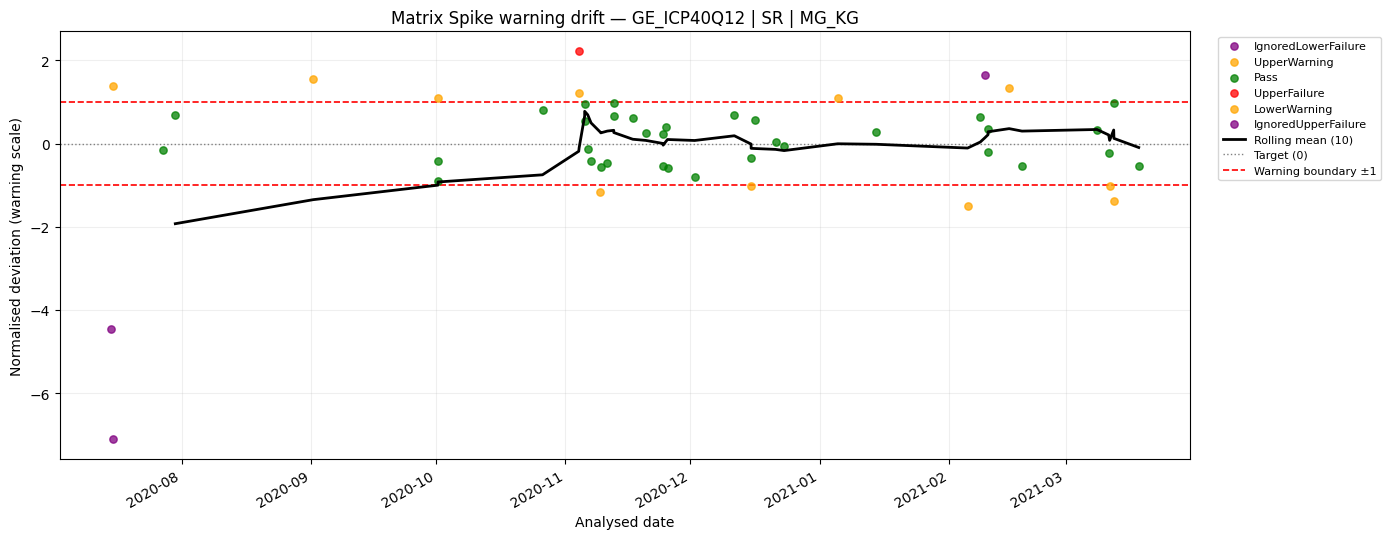

Failure drift example: GE_ICP40Q12 | PB | MG_KG


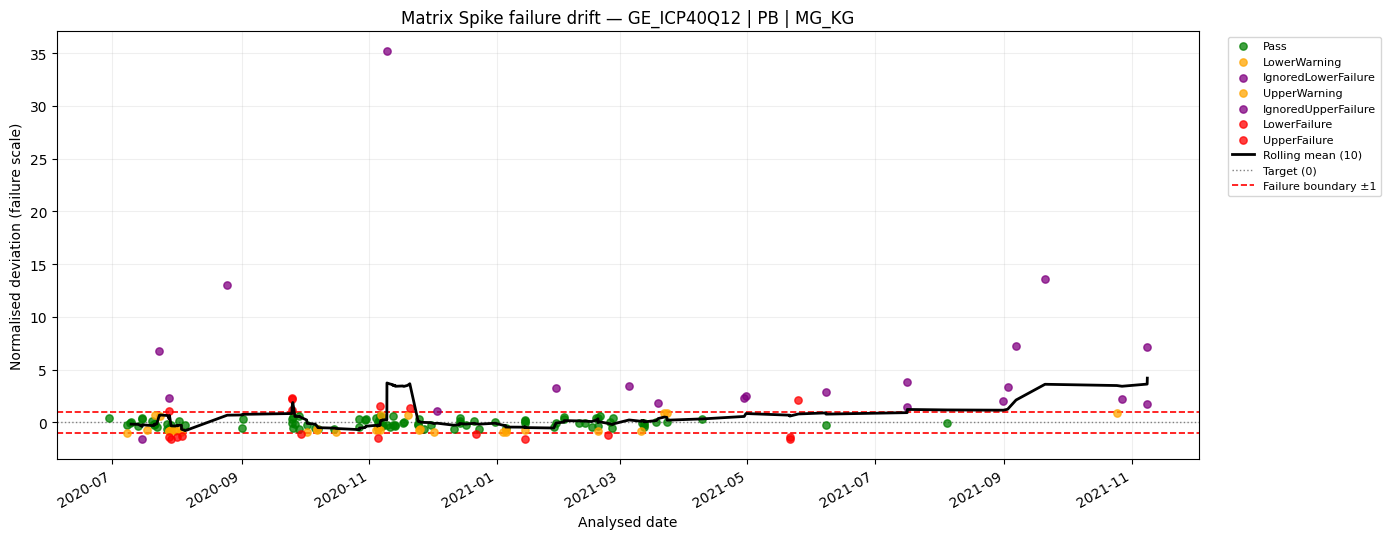

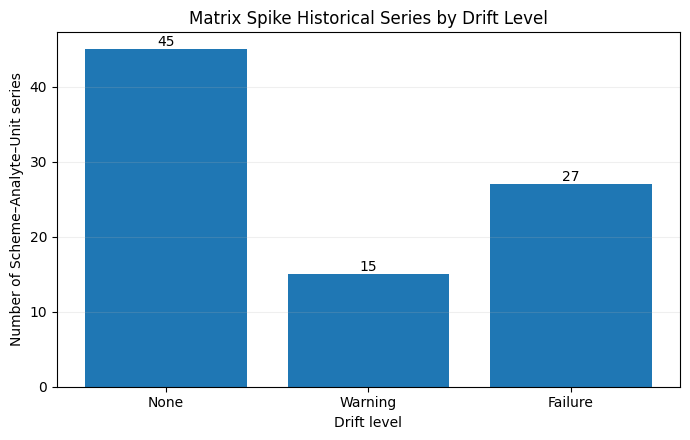


Overall drift-level counts:
drift_level
None       45
Warning    15
Failure    27

Total historical series: 87


In [15]:
status_colours = {
    "Pass": "green",
    "UpperWarning": "orange",
    "LowerWarning": "orange",
    "UpperFailure": "red",
    "LowerFailure": "red",
    "IgnoredUpperFailure": "purple",
    "IgnoredLowerFailure": "purple",
    "NotTested": "gray"
}


def plot_ms_drift(
    frame,
    scheme_code,
    analyte_code,
    unit_code,
    value_col="Normalized_Warning",
    title_scale="Warning",
    custom_title=None
):
    """
    Plot one Matrix Spike historical series on a normalised scale.

    Points show individual results and are coloured by STANDARD_STATUS.
    The black line shows the rolling mean used by the drift detector.

    On the normalised scale:
        0  = internal target
        +1 = upper Warning/Failure boundary
        -1 = lower Warning/Failure boundary
    """

    group = frame[
        (frame["SCHEME_CODE"] == scheme_code) &
        (frame["ANALYTE_CODE"] == analyte_code) &
        (frame["UNIT_CODE"] == unit_code)
    ].copy()

    group = (
        group
        .sort_values("ANALYSED_DATE")
        .reset_index(drop=True)
    )

    if group.empty:
        print("No matching Matrix Spike series found.")
        return

    win = min(ROLLING_WINDOW, len(group))
    min_periods = max(1, win // 2)

    group["ROLLING"] = (
        group[value_col]
        .rolling(
            window=win,
            min_periods=min_periods
        )
        .mean()
    )

    fig, ax = plt.subplots(figsize=(14, 5.5))

    for status in group["STANDARD_STATUS"].drop_duplicates():

        status_data = group[
            group["STANDARD_STATUS"] == status
        ]

        ax.scatter(
            status_data["ANALYSED_DATE"],
            status_data[value_col],
            s=28,
            alpha=0.75,
            color=status_colours.get(status, "gray"),
            label=status,
            zorder=3
        )

    ax.plot(
        group["ANALYSED_DATE"],
        group["ROLLING"],
        color="black",
        linewidth=2,
        label=f"Rolling mean ({win})",
        zorder=4
    )

    ax.axhline(
        0,
        color="gray",
        linestyle=":",
        linewidth=1.0,
        label="Target (0)"
    )

    ax.axhline(
        1,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"{title_scale} boundary ±1"
    )

    ax.axhline(
        -1,
        color="red",
        linestyle="--",
        linewidth=1.2
    )

    ax.set_xlabel("Analysed date")

    ax.set_ylabel(
        f"Normalised deviation ({title_scale.lower()} scale)"
    )

    ax.set_title(
        custom_title
        if custom_title is not None
        else (
            f"Matrix Spike {title_scale.lower()} drift — "
            f"{scheme_code} | {analyte_code} | {unit_code}"
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    fig.autofmt_xdate()

    ax.grid(alpha=0.2)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()


warning_only = drift_summary[
    (drift_summary["warning_drift_detected"]) &
    (~drift_summary["failure_drift_detected"])
].copy()

if not warning_only.empty:

    readable_warning = warning_only[
        warning_only["peak_abs_warning_score"] <= 5
    ]

    if not readable_warning.empty:
        warning_example = readable_warning.iloc[0]
    else:
        warning_example = warning_only.iloc[0]

    print(
        "Warning-only drift example:",
        warning_example["SCHEME_CODE"],
        "|",
        warning_example["ANALYTE_CODE"],
        "|",
        warning_example["UNIT_CODE"]
    )

    plot_ms_drift(
        ms_drift,
        warning_example["SCHEME_CODE"],
        warning_example["ANALYTE_CODE"],
        warning_example["UNIT_CODE"],
        value_col="Normalized_Warning",
        title_scale="Warning"
    )

else:
    print("No Warning-only drift series were detected.")


if not failure_drift_summary.empty:

    readable_failure = failure_drift_summary[
        failure_drift_summary["peak_abs_failure_score"] <= 5
    ]

    if not readable_failure.empty:
        failure_example = readable_failure.iloc[0]
    else:
        failure_example = failure_drift_summary.iloc[0]

    print(
        "Failure drift example:",
        failure_example["SCHEME_CODE"],
        "|",
        failure_example["ANALYTE_CODE"],
        "|",
        failure_example["UNIT_CODE"]
    )

    plot_ms_drift(
        ms_drift,
        failure_example["SCHEME_CODE"],
        failure_example["ANALYTE_CODE"],
        failure_example["UNIT_CODE"],
        value_col="Normalized_Failure",
        title_scale="Failure"
    )

else:
    print("No Failure drift series were detected.")


level_counts = (
    drift_summary["drift_level"]
    .value_counts()
    .reindex(
        ["None", "Warning", "Failure"],
        fill_value=0
    )
)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    level_counts.index,
    level_counts.values
)

ax.set_title(
    "Matrix Spike Historical Series by Drift Level"
)

ax.set_xlabel(
    "Drift level"
)

ax.set_ylabel(
    "Number of Scheme–Analyte–Unit series"
)

ax.grid(
    axis="y",
    alpha=0.2
)

for bar, value in zip(
    bars,
    level_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(value)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


print("\nOverall drift-level counts:")
print(level_counts.to_string())

print(
    f"\nTotal historical series: "
    f"{int(level_counts.sum())}"
)


No-drift example: GE_IMS40Q12 | Y | MG_KG


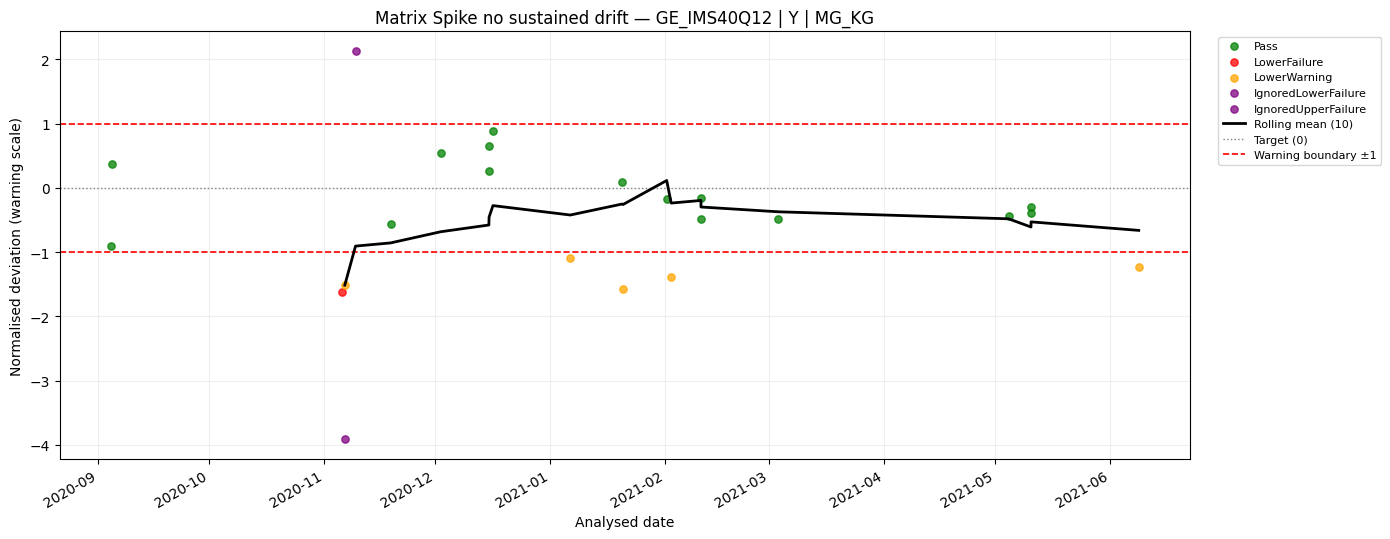

In [16]:
# No-drift example
# Select a Scheme–Analyte–Unit series that did not meet either
# the sustained Warning-drift or Failure-drift condition.

no_drift = drift_summary[
    (~drift_summary["warning_drift_detected"]) &
    (~drift_summary["failure_drift_detected"])
].copy()

if not no_drift.empty:

    # Prefer a visually readable example without extremely large
    # warning-normalised values.
    readable_none = no_drift[
        no_drift["peak_abs_warning_score"] <= 5
    ].copy()

    if not readable_none.empty:
        no_drift_example = readable_none.iloc[0]
    else:
        no_drift_example = no_drift.iloc[0]

    scheme = no_drift_example["SCHEME_CODE"]
    analyte = no_drift_example["ANALYTE_CODE"]
    unit = no_drift_example["UNIT_CODE"]

    print(
        f"No-drift example: {scheme} | {analyte} | {unit}"
    )

    plot_ms_drift(
        ms_drift,
        scheme,
        analyte,
        unit,
        value_col="Normalized_Warning",
        title_scale="Warning",
        custom_title=(
            "Matrix Spike no sustained drift — "
            f"{scheme} | {analyte} | {unit}"
        )
    )

else:
    print("No non-drift Matrix Spike series were available.")


Although this series contains individual Warning/Failure results, the rolling historical behaviour does not remain beyond the warning boundary for three consecutive observations. Therefore, it is not classified as sustained drift.


### 9.1 POC parameter sensitivity

The rolling window and consecutive-breach requirement are **proof-of-concept settings**, 

The main detector uses a rolling window of **10 observations** and requires **3 consecutive same-direction rolling breaches**. The sensitivity check below repeats the same detector logic using nearby parameter choices to show how dependent the number of review candidates is on those POC settings.

This analysis is diagnostic only. It does not define a new operational threshold.


In [17]:
def detect_with_settings(frame, rolling_window, consecutive_required):
    """Repeat the same MS drift logic using alternative POC settings."""
    rows = []
    group_keys = ["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]

    for keys, group in frame.groupby(group_keys, sort=True):

        g = (
            group
            .sort_values("ANALYSED_DATE")
            .reset_index(drop=True)
            .copy()
        )

        win = min(rolling_window, len(g))
        min_periods = max(1, win // 2)

        warning_roll = (
            g["Normalized_Warning"]
            .rolling(
                window=win,
                min_periods=min_periods
            )
            .mean()
        )

        warning_detected, _, _ = (
            first_consecutive_directional_breach(
                warning_roll,
                g["ANALYSED_DATE"],
                threshold=BOUNDARY_LEVEL,
                consecutive_required=consecutive_required
            )
        )

        failure_roll = (
            g["Normalized_Failure"]
            .rolling(
                window=win,
                min_periods=min_periods
            )
            .mean()
        )

        if warning_detected:
            failure_detected, _, _ = (
                first_consecutive_directional_breach(
                    failure_roll,
                    g["ANALYSED_DATE"],
                    threshold=BOUNDARY_LEVEL,
                    consecutive_required=consecutive_required
                )
            )
        else:
            failure_detected = False

        rows.append({
            "SCHEME_CODE": keys[0],
            "ANALYTE_CODE": keys[1],
            "UNIT_CODE": keys[2],
            "warning_detected": bool(warning_detected),
            "failure_detected": bool(failure_detected)
        })

    return pd.DataFrame(rows)


sensitivity_rows = []

for window in [5, 10, 15]:
    for consecutive in [2, 3, 4]:

        result = detect_with_settings(
            ms_drift,
            rolling_window=window,
            consecutive_required=consecutive
        )

        sensitivity_rows.append({
            "rolling_window": window,
            "consecutive_required": consecutive,
            "warning_drift_series": int(
                result["warning_detected"].sum()
            ),
            "failure_drift_series": int(
                result["failure_detected"].sum()
            )
        })

sensitivity_results = pd.DataFrame(sensitivity_rows)

print("POC parameter sensitivity:")
display(sensitivity_results)

baseline_sensitivity = sensitivity_results[
    (sensitivity_results["rolling_window"] == ROLLING_WINDOW) &
    (sensitivity_results["consecutive_required"] == CONSECUTIVE_REQUIRED)
]

if not baseline_sensitivity.empty:
    print("\nBaseline configuration reproduced:")
    display(baseline_sensitivity.reset_index(drop=True))


POC parameter sensitivity:


,rolling_window,consecutive_required,warning_drift_series,failure_drift_series
0,5,2,52,40
1,5,3,49,35
2,5,4,48,32
3,10,2,45,27
4,10,3,42,27
5,10,4,36,23
6,15,2,35,22
7,15,3,34,22
8,15,4,34,18



Baseline configuration reproduced:


,rolling_window,consecutive_required,warning_drift_series,failure_drift_series
0,10,3,42,27


### 9.2 Structured Matrix Spike analyst-review output

The table below consolidates each flagged historical series into a review-oriented output.

The historical drift level is supplementary to `STANDARD_STATUS`. It does not replace the existing CCLAS row-level classification. The table keeps the series identifiers, direction, onset dates, current and peak historical scores, existing CCLAS status counts, and basic history size information required for traceability.


In [18]:
review_output = drift_cclas_comparison[
    drift_cclas_comparison["drift_level"] != "None"
].copy()

review_output["review_order"] = (
    review_output["drift_level"]
    .map({
        "Failure": 1,
        "Warning": 2
    })
)

review_output = (
    review_output
    .sort_values(
        [
            "review_order",
            "peak_abs_warning_score"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

review_columns = [
    "SCHEME_CODE",
    "ANALYTE_CODE",
    "UNIT_CODE",
    "drift_level",
    "warning_direction",
    "warning_drift_start",
    "failure_direction",
    "failure_drift_start",
    "current_warning_score",
    "peak_abs_warning_score",
    "peak_abs_failure_score",
    "CCLAS_Pass_Count",
    "CCLAS_Warning_Count",
    "CCLAS_Active_Failure_Count",
    "CCLAS_Ignored_Failure_Count",
    "n_observations",
    "n_jobs",
    "n_instruments"
]

print(
    f"Historical Matrix Spike series requiring review: "
    f"{len(review_output):,}"
)

display(
    review_output[review_columns]
)


Historical Matrix Spike series requiring review: 42


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,drift_level,warning_direction,warning_drift_start,failure_direction,failure_drift_start,current_warning_score,peak_abs_warning_score,peak_abs_failure_score,CCLAS_Pass_Count,CCLAS_Warning_Count,CCLAS_Active_Failure_Count,CCLAS_Ignored_Failure_Count,n_observations,n_jobs,n_instruments
0,GE_ICP40Q12,AG,MG_KG,Failure,Upper,2020-11-04 07:56:06.000,Upper,2020-11-04 07:56:06.000,0.664226,326.140814,206.865803,146,10,1,0,157,128,0
1,GE_ICP40Q12,SE,MG_KG,Failure,Upper,2020-07-10 03:22:44.000,Upper,2020-07-10 03:22:44.000,2.391001,111.570107,70.764806,17,16,81,5,119,97,0
2,GE_IMS40Q12,TL,MG_KG,Failure,Upper,2020-07-28 11:23:33.000,Upper,2021-03-30 09:56:12.000,0.131002,38.663029,24.524685,37,9,0,5,51,42,0
3,GE_ICP40Q12,PB,MG_KG,Failure,Upper,2020-07-23 15:28:18.000,Upper,2020-09-25 01:56:18.000,6.599683,6.599683,4.185988,94,31,18,21,164,131,0
4,GE_ICP40Q12,P,PERC,Failure,Upper,2020-11-04 07:56:06.000,Upper,2020-11-04 07:56:06.000,0.056513,5.967882,3.785584,67,7,1,2,77,57,0
5,GE_IMS40Q12,CD,MG_KG,Failure,Upper,2020-11-05 20:15:06.000,Upper,2020-11-05 20:15:06.000,3.946771,5.390887,3.420073,2,6,1,14,23,17,0
6,GE_ICP40Q12,U,MG_KG,Failure,Lower,2020-11-17 04:51:51.000,Lower,2020-11-17 04:51:51.000,-3.765018,4.777107,3.029799,8,7,11,21,47,37,0
7,GE_IMS40Q12,CO,MG_KG,Failure,Upper,2020-09-04 17:36:02.000,Upper,2020-09-04 17:36:02.000,1.397340,4.628892,2.937415,20,4,1,5,30,22,0
8,GE_ICP40Q12,MO,MG_KG,Failure,Upper,2020-07-20 05:29:35.000,Upper,2020-09-25 03:26:01.000,-0.576559,4.266409,2.707307,58,24,42,12,136,111,0
9,GE_ICP40Q12,CA,PERC,Failure,Upper,2020-08-25 03:34:49.000,Upper,2020-08-25 03:34:49.000,-0.114913,3.660928,2.321483,55,15,1,5,76,58,0


## 10. Submission validation checks


In [19]:
# Data-integrity and logic checks for a clean submission run.
expected_series = (
    ms_drift[["SCHEME_CODE", "ANALYTE_CODE", "UNIT_CODE"]]
    .drop_duplicates()
    .shape[0]
)

assert len(ms_drift) == int(valid_history_mask.sum())
assert len(drift_summary) == expected_series
assert (ms_drift["ANALYTE_CODE"] == "NA").any(), "Legitimate analyte code 'NA' was lost."
assert failure_drift_summary["warning_drift_detected"].all(), (
    "Failure stage must only contain series that first passed the warning stage."
)
assert "Drift_Input_Warning" not in ms_drift.columns, "Clipped detector input should not be used."
assert "Drift_Input_Failure" not in ms_drift.columns, "Clipped detector input should not be used."
assert BOUNDARY_LEVEL == 1.0



# Extended checks for the added historical-review outputs.
assert len(review_output) == int(
    drift_summary["warning_drift_detected"].sum()
), (
    "Review output should contain every series with Warning-level "
    "or stronger sustained drift."
)

assert set(review_output["drift_level"]).issubset(
    {"Warning", "Failure"}
)

assert (
    drift_cclas_comparison[
        [
            "CCLAS_Pass_Count",
            "CCLAS_Warning_Count",
            "CCLAS_Active_Failure_Count",
            "CCLAS_Ignored_Failure_Count"
        ]
    ]
    .fillna(0)
    .ge(0)
    .all()
    .all()
)

baseline_check = sensitivity_results[
    (sensitivity_results["rolling_window"] == ROLLING_WINDOW) &
    (sensitivity_results["consecutive_required"] == CONSECUTIVE_REQUIRED)
]

assert len(baseline_check) == 1
assert int(baseline_check.iloc[0]["warning_drift_series"]) == len(warning_drift_summary)
assert int(baseline_check.iloc[0]["failure_drift_series"]) == len(failure_drift_summary)

print("Extended review-output validation checks passed.")

print("All submission validation checks passed.")
print(f"Rows analysed: {len(ms_drift):,}")
print(f"Unique analytes: {ms_drift['ANALYTE_CODE'].nunique():,}")
print(f"Historical series: {len(drift_summary):,}")
print(f"Warning-drift review series: {len(warning_drift_summary):,}")
print(f"Failure-drift review series: {len(failure_drift_summary):,}")


Extended review-output validation checks passed.
All submission validation checks passed.
Rows analysed: 6,958
Unique analytes: 58
Historical series: 87
Warning-drift review series: 42
Failure-drift review series: 27


## 11. Interpretation

This notebook extends the Matrix Spike historical time-series analysis from visual historical behaviour to explicit, traceable drift detection.

The time-series stage establishes how each result moves relative to its own target and supplied Warning/Failure limits. The drift stage then tests whether that movement becomes persistent across consecutive historical observations within the same **Scheme–Analyte–Unit** series.

The main outputs are:

- `warning_drift_detected`: sustained rolling movement has reached the Warning boundary;
- `warning_direction`: whether that sustained movement is above (`Upper`) or below (`Lower`) target;
- `warning_drift_start`: start date of the first qualifying sustained Warning sequence;
- `failure_drift_detected`: sustained rolling movement has reached the Failure boundary;
- `failure_direction`: direction of the sustained Failure movement;
- `failure_drift_start`: start date of the first qualifying sustained Failure sequence;
- `current_warning_score`: most recent rolling Warning-normalised value;
- `peak_abs_warning_score`: largest absolute rolling Warning-normalised value;
- `peak_abs_failure_score`: largest absolute rolling Failure-normalised value.

`STANDARD_STATUS` remains the existing row-level CCLAS QC result. The historical drift outputs are supplementary review signals and do not replace or redefine the existing CCLAS classifications.

The added review analysis provides:

1. a direct comparison between historical drift candidates and the row-level CCLAS statuses already present in each series;
2. an Upper-versus-Lower drift breakdown;
3. comparison of sustained drift onset with the first existing non-ignored CCLAS Warning/Failure date;
4. explicit reporting of ignored Failure rows rather than silently removing them;
5. sensitivity testing of the rolling-window and persistence settings;
6. a consolidated analyst-review table containing the identifiers, drift level, direction, onset, historical scores, CCLAS status counts and traceability information for every flagged series.

The rolling window of 10 observations and the requirement for 3 consecutive same-direction boundary breaches remain **proof-of-concept implementation settings**. They are not presented as official Datamine or CCLAS acceptance rules. The sensitivity analysis is included to show how the number of review candidates changes under nearby settings, and the final operational settings would require Datamine validation.

The notebook does not calculate Matrix Spike recovery percentage because the required parent/unspiked result and spike-added concentration are not available in the supplied data. It therefore reports only what can be calculated directly from the available Matrix Spike measurements, targets and QC limits.

Overall, the notebook identifies sustained historical movement while preserving the existing CCLAS classifications as the authoritative row-level QC outcomes. The purpose of the additional drift signal is to provide historical context and prioritise Scheme–Analyte–Unit series that may require analyst review.
